# Fake News Detection using Fine-Tuned FLAN-T5

## Data Loading and Preprocessing

**Course:** ADS-509 Applied Large Language Models for Data Science

**Team Project**

This notebook loads, explores, and preprocesses the Fake and Real News dataset for fine-tuning a Large Language Model.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

print(pd.__version__)

2.2.2


In [6]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\anish\notebooks
['.ipynb_checkpoints', '01_Data_Preprocessing.ipynb', '02_Exploratory_Data_Analysis.ipynb', '03_ZeroShot_FewShot.ipynb', '04_FLAN_T5_FineTuning.ipynb']


In [10]:
import csv

with open("../data/True.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    print(next(reader))
    print(next(reader))

['title', 'text', 'subject', 'date']
['As U.S. budget fight looms, Republicans flip their fiscal script', 'WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats

In [12]:
import csv

count = 0

with open("../data/True.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)

    try:
        for row in reader:
            count += 1
    except Exception as e:
        print("Stopped at row:", count)
        print(e)

print("Rows successfully read:", count)

Rows successfully read: 21418


In [16]:
import os

print(os.path.getsize("../data/True.csv"))

53582940


In [18]:
import pandas as pd

true = pd.read_csv(
    "../data/True.csv",
    engine="python",
    sep=",",
    quotechar='"',
    encoding="utf-8",
    on_bad_lines="skip"
)

print(true.shape)

(21417, 4)


In [20]:
fake = pd.read_csv("../data/Fake.csv")
print(fake.shape)

(23481, 4)


In [22]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

In [24]:
print("Fake News Dataset")
display(fake.head())

print("\nReal News Dataset")
display(true.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



Real News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [26]:
print("Fake Dataset Shape:", fake.shape)
print("Real Dataset Shape:", true.shape)

print("\nFake Dataset Info")
fake.info()

print("\nReal Dataset Info")
true.info()

Fake Dataset Shape: (23481, 4)
Real Dataset Shape: (21417, 4)

Fake Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB

Real Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [28]:
print("Missing Values in Fake Dataset")
print(fake.isnull().sum())

print("\nMissing Values in Real Dataset")
print(true.isnull().sum())

Missing Values in Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64

Missing Values in Real Dataset
title      0
text       0
subject    0
date       0
dtype: int64


In [30]:
print("Fake duplicates:", fake.duplicated().sum())
print("Real duplicates:", true.duplicated().sum())

Fake duplicates: 3
Real duplicates: 206


In [32]:
fake = fake.drop_duplicates()
true = true.drop_duplicates()

print(fake.shape)
print(true.shape)

(23478, 4)
(21211, 4)


In [34]:
fake["label"] = 0
true["label"] = 1

In [36]:
df = pd.concat([fake, true], ignore_index=True)

In [38]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [40]:
df.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


In [42]:
print(df.shape)

(44689, 5)


In [44]:
print(df["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


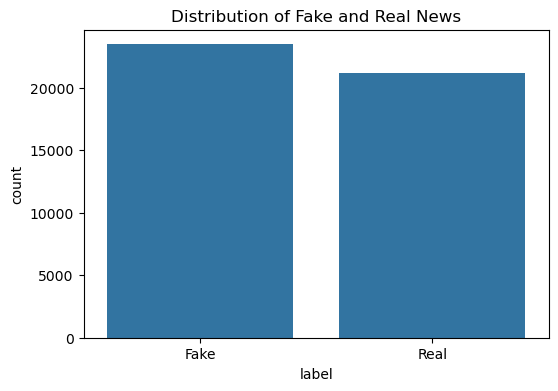

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Distribution of Fake and Real News")

plt.xticks([0,1],["Fake","Real"])

plt.show()

In [48]:
df["content"] = df["title"] + ". " + df["text"]

In [50]:
df = df[["content", "label"]]

df.head()

,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,0


In [52]:
import csv

# Remove embedded newlines
df["content"] = (
    df["content"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("\r", " ", regex=False)
)

# Remove multiple spaces
df["content"] = df["content"].str.replace(r"\s+", " ", regex=True)

# Save safely
df.to_csv(
    "clean_news.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL,
    escapechar="\\"
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [53]:
test = pd.read_csv("clean_news.csv")

print(test.shape)

test.head()

(44689, 2)


,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,0
